# Description

This is an example of using the [Deepsensor package](https://alan-turing-institute.github.io/deepsensor/index.html) to infer surface NO2 concentrations with multiple input data sources.

[Installation instructions for the Deepsensor package and dependencies.](https://alan-turing-institute.github.io/deepsensor/getting-started/installation.html)

## Setup

A conda environment `deepsensor_cenv` was set up for the deepsensor package and its dependencies.

This was made available as a Kernel in JupyterHub: `Python [conda env:.conda-deepsensor_cenv]`

In [1]:
# Basic packages:
import os
import logging
logging.captureWarnings(True)

# Data management packages:
import numpy as np
import xarray as xr
import pandas as pd

# Plotting packages:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Deepsensor:
import deepsensor.torch
from deepsensor.data import DataProcessor
from deepsensor.data import TaskLoader
from deepsensor.data import construct_circ_time_ds
from deepsensor.model import ConvNP
from deepsensor.train import Trainer, set_gpu_default_device

# input data
s_data_folder = "/discover/nobackup/cmalings/input/ASIA-AQ Experimentation"
s_data_folder_GCAS = "/discover/nobackup/cmalings/input/ASIA-AQ GCAS Simulation"

# working data folder and file
processor_dir = "/discover/nobackup/cmalings/output/ASIA-AQ/deepsensor_working_data/test_3/"
data_fpath = os.path.join(processor_dir,"tmp.nc")

b_Retrain_Model = False

__*Note*__: to enable plotting of new regions, the region must be defined for the deepsensor plotting function.

File to modify: `/discover/nobackup/cmalings/.conda/envs/deepsensor_cenv/lib/python3.13/site-packages/deepsensor/plot.py`

Function to modufy: `extent_str_to_tuple` (line 1068)

Modification to make: add to the list
```
elif extent == 'new_region':
    return (min_lon,max_lon,min_lat,max_lat)
```

__*Also Note*__: Plotting is currently not working on NCCS Jupyterhub since this doesn't have the internet access needed to download the shapefiles. A temporary workaround is included for showing results.

## Load Data

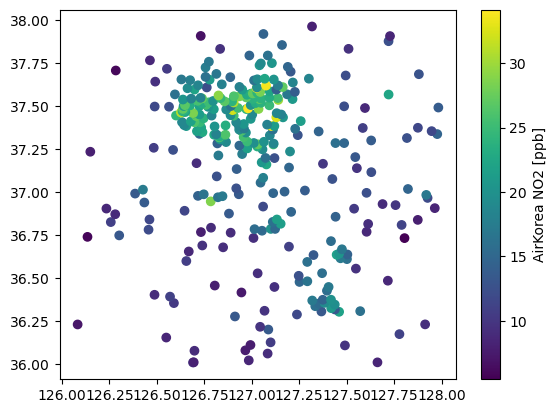

In [2]:
# Load AirKorea Data
f_data_airkorea_raw = pd.read_csv(os.path.join(s_data_folder,'AirKorea_AsiaAQ_Seoul_station_h.csv'))

# Ensure DateTime Formatting:
f_data_airkorea_raw['time'] = pd.to_datetime(f_data_airkorea_raw['time'])

# Only retain data to be used here, and set the index to the proper sequence (time, lat, lon):
f_data_airkorea = f_data_airkorea_raw[['lat','lon','time','NO2']].set_index(['time','lat','lon'])

# Check Data
f_data_airkorea_avg = f_data_airkorea.groupby(['lat','lon']).mean('time').reset_index()
plt.scatter(f_data_airkorea_avg['lon'],f_data_airkorea_avg['lat'],c=f_data_airkorea_avg['NO2'])
plt.colorbar(label='AirKorea NO2 [ppb]')
plt.show()

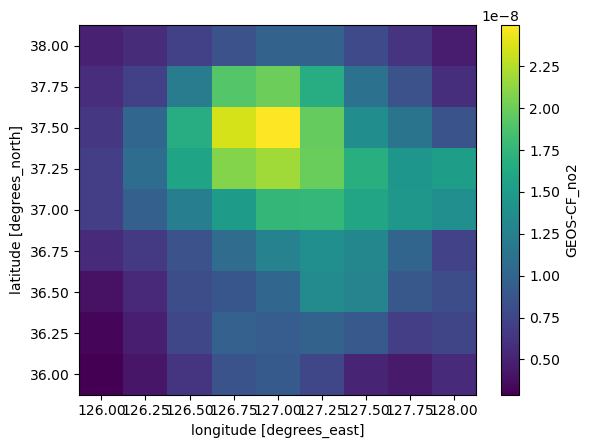

In [37]:
# Load GOES-CF Data
a_data_GEOSCF_raw = xr.open_dataset(os.path.join(s_data_folder,'GEOS-CF_AsiaAQ_Seoul_Grid_025_h.nc'))

# Only retain data to be used here, and set the dimensions to the proper sequence (time, lat, lon):
a_data_GEOSCF = a_data_GEOSCF_raw[['no2',
                                   'tropcol_no2',
                                   'totcol_no2',
                                   'u2m',
                                   'v2m',
                                   'wndspd_2m',
                                   't2m',
                                   'q2m',
                                   'rh',
                                   'cldtt',
                                   'tprec',
                                   'troppb',
                                   'zl',
                                   'zpbl',
                                  ]].transpose('time','lat','lon')

# Append data source to variable names:
a_data_GEOSCF = a_data_GEOSCF.rename({s_var:'GEOS-CF_'+s_var for s_var in a_data_GEOSCF})

# Check Data
a_data_GEOSCF['GEOS-CF_no2'].mean('time').plot()

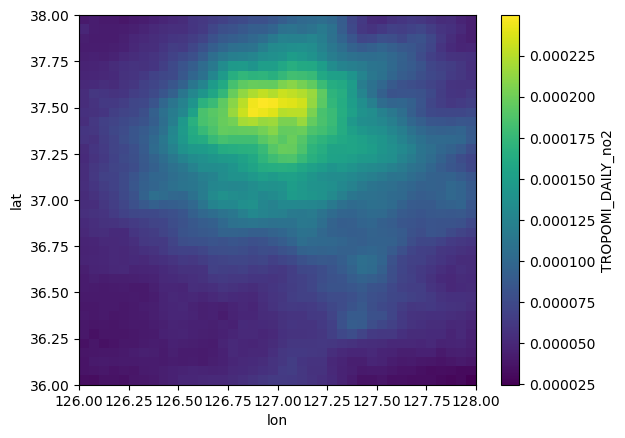

In [28]:
# Load TROPOMI Data
a_data_TROPOMI_raw = xr.open_dataset(os.path.join(s_data_folder,'TROPOMI_AsiaAQ_Seoul_Regrid_005_h.nc'))

# Only retain data to be used here, and set the dimensions to the proper sequence (time, lat, lon):
a_data_TROPOMI = a_data_TROPOMI_raw[['no2','o3']].transpose('time','lat','lon')

# Append data source to variable names:
a_data_TROPOMI = a_data_TROPOMI.rename({s_var:'TROPOMI_'+s_var for s_var in a_data_TROPOMI})

# Create Daily-aggregate TROPOMI Data:
# Define "days" centered at nominal overpass time:
v_days = np.arange(np.datetime64('2024-02-01T04:30:00'),np.datetime64('2024-03-31T23:59:59'),np.timedelta64(1,'D'))
# Match each overpass with the nearest nominal day:
v_day_assignments = [v_days[np.argmin(abs(v_days - t_time))] for t_time in a_data_TROPOMI.time.values]
# Use coordinate grouping and averaging to create daily averages:
a_data_TROPOMI_daily = a_data_TROPOMI.assign_coords({'date':('time',v_day_assignments)}).groupby('date').mean('time')
# Rename variables and dimensions:
a_data_TROPOMI_daily = a_data_TROPOMI_daily.rename({'date':'time'})
a_data_TROPOMI_daily = a_data_TROPOMI_daily.rename({s_var:s_var.replace('TROPOMI_','TROPOMI_DAILY_') for s_var in a_data_TROPOMI})

# Check Data:
a_data_TROPOMI_daily['TROPOMI_DAILY_no2'].mean('time').plot()

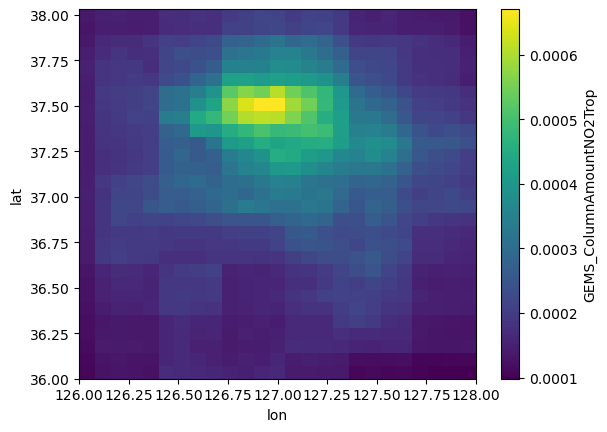

In [29]:
# Load GEMS
a_data_GEMS_raw = xr.open_dataset(os.path.join(s_data_folder,'GEMS_AsiaAQ_Seoul_Regrid_008_h.nc'))

# Only retain data to be used here, and set the dimensions to the proper sequence (time, lat, lon):
a_data_GEMS = a_data_GEMS_raw[['ColumnAmountNO2Trop','ColumnAmountNO2']].transpose('time','lat','lon')

# Append data source to variable names:
a_data_GEMS = a_data_GEMS.rename({s_var:'GEMS_'+s_var for s_var in a_data_GEMS})

# Check Data
a_data_GEMS['GEMS_ColumnAmountNO2Trop'].mean('time').plot()

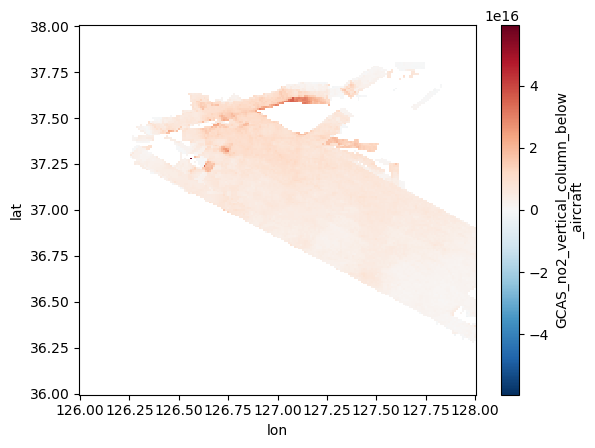

In [30]:
# Load GCAS Data
# Days with GCAS overflight:
l_days_GCAS = [
              '20240217',
              '20240223',
              '20240226',
              '20240301',
              '20240302',
              '20240303',
              '20240307',
              '20240309'
              ]

# GCAS data variables to be used:
l_GCAS_vars_to_keep = ['no2_vertical_column_below_aircraft','model_no2_vertical_column_below_aircraft']

# Load and concatenate by time, and set the dimensions to the proper sequence (time, lat, lon):
l_data_GCAS = [xr.open_dataset(os.path.join(s_data_folder_GCAS,f'GCAS_NO2_{s_day}_Seoul_Gridded_001_hourly.nc'))[l_GCAS_vars_to_keep] for s_day in l_days_GCAS]
a_data_GCAS = xr.concat(l_data_GCAS,'time').transpose('time','lat','lon')

# Append data source to variable names:
a_data_GCAS = a_data_GCAS.rename({s_var:'GCAS_'+s_var for s_var in a_data_GCAS})

# Check Data
a_data_GCAS['GCAS_no2_vertical_column_below_aircraft'].mean('time').plot()

## Align all data to common times

The Deepsensor package uses `time` as its indexing dimension; essentially, `time` is used to match up information across the different context and target datasets, to identify which data should be grouped together as representing the "same thing". For time-series applications, you can specify lags so that data from adjacent times can be considerred as inputs; however, **Deepsensor assumes that `time` is evenly spaced**; if this is not the case, it will cause issues. Here, we are just using the time as an indexing, so we will ignore that requirement. 

To ensure things will work properly, we need to align all of our inputs to have a common time vector, filling in blanks where needed.

In [38]:
# Function to align times
def F_align_times(a_in,v_time,dt_tol = np.timedelta64(30,'m')):
    # Convert Data Frames to Xarray:
    if (type(a_in) == pd.DataFrame):
        b_frame = True
        a_in = a_in.to_xarray()
    else:
        b_frame = False
    # Use re-indexing with tolerance to get the nearest time in the sample:
    a_out = a_in.reindex(time=v_time,
                         method="nearest",
                         tolerance=dt_tol,
                         copy=False,
                         kwargs={'fill_value':'extrapolate'})
    # Convert back to dataframe if needed:
    if b_frame:
        a_out = a_out.to_dataframe().dropna(how='all')
    return a_out


# Target times: AirKorea Monitor Data
# v_time = f_data_airkorea.reset_index()['time'].unique()

# Target times: GCAS Flights
v_time = a_data_GCAS.time.values

f_data_airkorea_aligned = F_align_times(f_data_airkorea,v_time)
a_data_GEOSCF_aligned = F_align_times(a_data_GEOSCF,v_time) # 7MB
a_data_TROPOMI_daily_aligned = F_align_times(a_data_TROPOMI_daily,v_time,dt_tol = np.timedelta64(12,'h')) # 37MB
a_data_GEMS_aligned = F_align_times(a_data_GEMS,v_time) # 17MB
a_data_GCAS_aligned = F_align_times(a_data_GCAS,v_time) # 925MB !!!

# Verify alignment
b_aligned = True
if len(v_time) != len(f_data_airkorea_aligned.reset_index()['time'].unique()):
    b_aligned = False
    print('Warning: AirKorea data are not temporally aligned.')
if len(v_time) != len(a_data_GEOSCF_aligned.time.values):
    b_aligned = False
    print('Warning: GEOS-CF data are not temporally aligned.')
if len(v_time) != len(a_data_TROPOMI_daily_aligned.time.values):
    b_aligned = False
    print('Warning: TROPOMI data are not temporally aligned.')
if len(v_time) != len(a_data_GEMS_aligned.time.values):
    b_aligned = False
    print('Warning: GEMS data are not temporally aligned.')
if len(v_time) != len(a_data_GCAS_aligned.time.values):
    b_aligned = False
    print('Warning: GCAS data are not temporally aligned.')
if b_aligned:
    print('All data are aligned.')


All data are aligned.


## Process Data

In [43]:
# Define Data Processor
data_processor = DataProcessor(x1_name="lat", x2_name="lon")

# Process Data:
f_data_airkorea_processed = data_processor(f_data_airkorea_aligned, method='positive_semidefinite')
a_data_GEOSCF_processed = data_processor(a_data_GEOSCF_aligned, method='mean_std')
a_data_TROPOMI_processed = data_processor(a_data_TROPOMI_daily_aligned, method='positive_semidefinite')
a_data_GEMS_processed = data_processor(a_data_GEMS_aligned, method='positive_semidefinite')
a_data_GCAS_processed = data_processor(a_data_GCAS_aligned, method='mean_std')

print(data_processor)

data_processor.save(processor_dir)

# !!! Create additional training data via rotations...

DataProcessor with normalisation params:
{'GCAS_model_no2_vertical_column_below_aircraft': {'method': 'mean_std',
                                                   'params': {'mean': 1.06595346960299e+16,
                                                              'std': 5756306096572272.0}},
 'GCAS_no2_vertical_column_below_aircraft': {'method': 'mean_std',
                                             'params': {'mean': 6003080262141303.0,
                                                        'std': 5572280285133337.0}},
 'GEMS_ColumnAmountNO2': {'method': 'positive_semidefinite',
                          'params': {'min': 9.672454325482249e-05,
                                     'std': 0.00013743046249498495}},
 'GEMS_ColumnAmountNO2Trop': {'method': 'positive_semidefinite',
                              'params': {'min': 7.191766053438187e-05,
                                         'std': 0.0001146099255920845}},
 'GEOS-CF_cldtt': {'method': 'mean_std',
                   

## Define a Task

TaskLoader(4 context sets, 1 target sets)
Context variable IDs: (('GCAS_no2_vertical_column_below_aircraft', 'GCAS_model_no2_vertical_column_below_aircraft'), ('GEMS_ColumnAmountNO2Trop', 'GEMS_ColumnAmountNO2'), ('TROPOMI_DAILY_no2', 'TROPOMI_DAILY_o3'), ('GEOS-CF_no2', 'GEOS-CF_tropcol_no2', 'GEOS-CF_totcol_no2', 'GEOS-CF_u2m', 'GEOS-CF_v2m', 'GEOS-CF_wndspd_2m', 'GEOS-CF_t2m', 'GEOS-CF_q2m', 'GEOS-CF_rh', 'GEOS-CF_cldtt', 'GEOS-CF_tprec', 'GEOS-CF_troppb', 'GEOS-CF_zl', 'GEOS-CF_zpbl', 'time_of_day'))
Target variable IDs: (('NO2',),)
time: 2024-02-17 01:30:00
ops: []
X_c: [((1, 201), (1, 201)), ((1, 29), (1, 25)), ((1, 40), (1, 40)), ((1, 9), (1, 9))]
Y_c: [(2, 201, 201), (2, 29, 25), (2, 40, 40), (15, 9, 9)]
X_t: [(2, 306)]
Y_t: [(1, 306)]



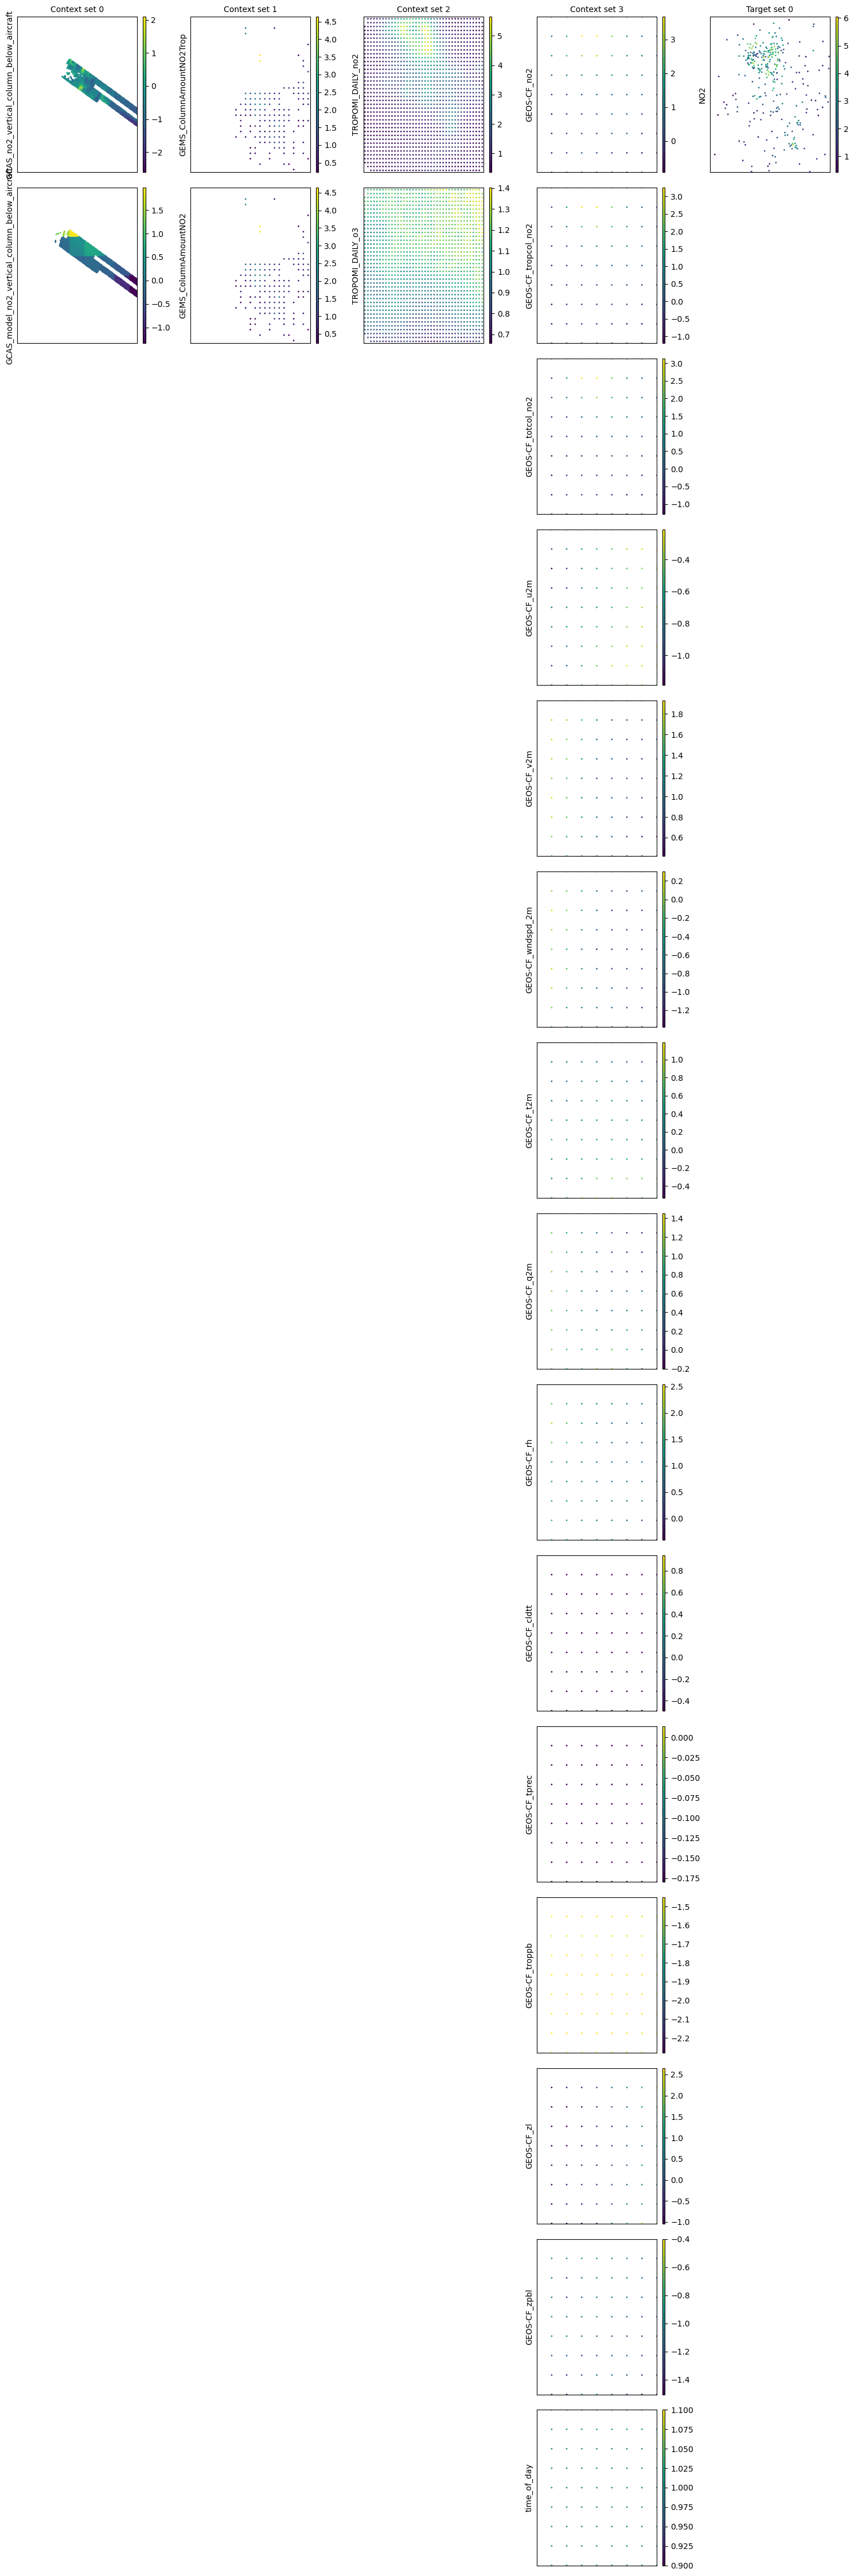

In [49]:
# Define the task loader:
task_loader = TaskLoader(
    context=[a_data_GCAS_processed,
             a_data_GEMS_processed,
             a_data_TROPOMI_processed,
             xr.merge([a_data_GEOSCF_processed,xr.DataArray(pd.to_datetime(v_time).hour,dims=('time'),coords={'time':v_time},name='time_of_day')]) # Add a time-of-day auxiliary variable
            ],
    target=f_data_airkorea_processed,
)
print(task_loader)
# task_loader.save(processor_dir)

# Create a task using the task loader:
task = task_loader('2024-02-17 01:30:00', context_sampling="all", target_sampling="all")
print(task)

# Visualize the task:
deepsensor.plot.task(task, task_loader)
plt.show()

## Define a Convolutional Neural Process Model

dim_yc inferred from TaskLoader: (2, 2, 2, 15)
dim_yt inferred from TaskLoader: 1
dim_aux_t inferred from TaskLoader: 0
internal_density inferred from TaskLoader: 333
encoder_scales inferred from TaskLoader: [np.float32(0.0025599145), np.float32(0.017919404), np.float32(0.012799574), np.float32(0.063997865)]
decoder_scale inferred from TaskLoader: 0.003003003003003003
ConvNP with config:
{
    "dim_x": 2,
    "dim_yc": [
        2,
        2,
        2,
        15
    ],
    "dim_yt": 1,
    "dim_aux_t": 0,
    "dim_lv": 0,
    "conv_arch": "unet",
    "unet_channels": [
        32,
        32,
        32,
        32,
        32
    ],
    "unet_resize_convs": true,
    "unet_resize_conv_interp_method": "bilinear",
    "aux_t_mlp_layers": null,
    "likelihood": "het",
    "unet_kernels": 5,
    "internal_density": 333,
    "encoder_scales": [
        0.0025599144864827394,
        0.017919404432177544,
        0.012799574062228203,
        0.06399786472320557
    ],
    "encoder_scale

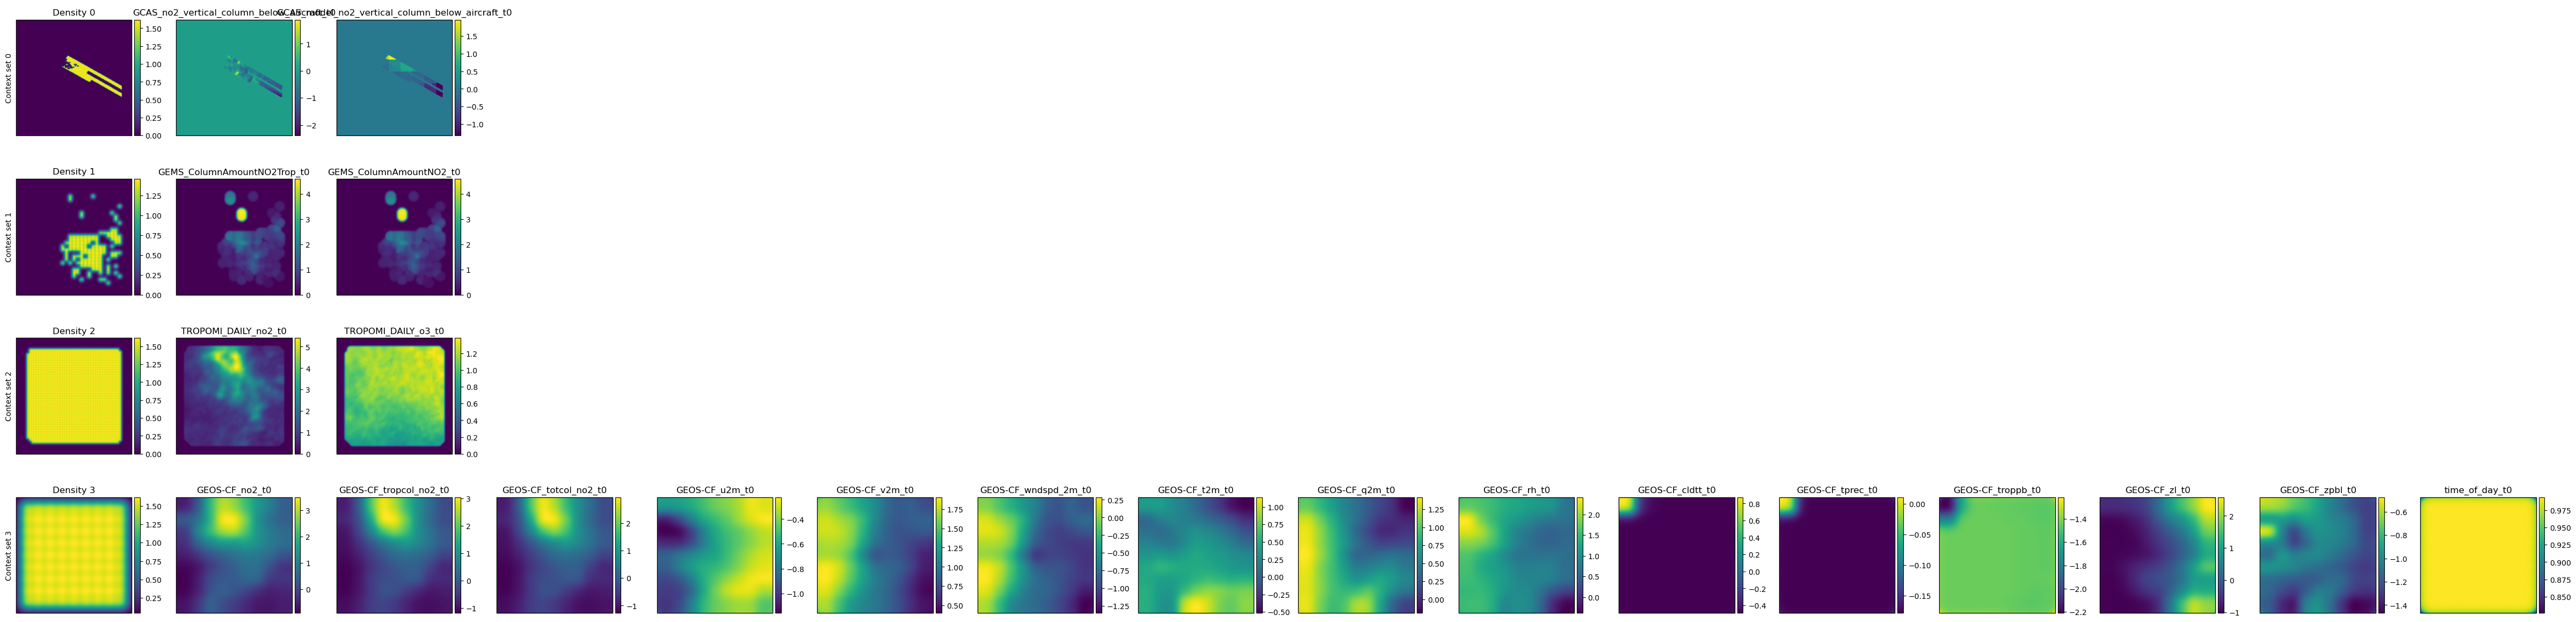

In [50]:
if b_Retrain_Model:
    model = ConvNP(data_processor, task_loader, unet_channels=(32, 32, 32, 32, 32))
    
    # Fix a bug: JSON is not able to encode numpy float32:
    model.config['encoder_scales'] = [float(number) for number in model.config['encoder_scales']]

    # Save the model
    model.save(processor_dir)
else:
    model = ConvNP(data_processor, task_loader, processor_dir)
print(model)

# encode a task to tensor and visualize the encoding
task = task_loader("2024-02-17 01:30:00'", "all", "all")
encoding = deepsensor.model.nps.compute_encoding_tensor(model, task)
print(f"SetConv encoding tensor shape: {encoding.shape}")
fig = deepsensor.plot.context_encoding(model, task, task_loader)
plt.show()

# visualize the receptive field (note: will not work without internet access to download shapefiles)
# fig = deepsensor.plot.receptive_field(model.model.receptive_field, data_processor, ccrs.PlateCarree(), "seoul")
# fig.axes[0].add_feature(cfeature.BORDERS, linestyle=':')
# plt.show()



## Set Up Training

In [51]:
if b_Retrain_Model:
    task_loader.load_dask()
    
    # Define task Generator
    def gen_tasks(dates, progress=True):
        tasks = []
        for date in dates:
            # N_c = np.random.randint(0, 500)
            task = task_loader(date, context_sampling=["all","all", "all", "all"], target_sampling="all")
            tasks.append(task)
        return tasks
    
    # Split times into training and evaluation sets:
    train_range = v_time[0:int(np.ceil(len(v_time)/1.25))]
    val_range = v_time[int(np.ceil(len(v_time)/1.25)):len(v_time)]
    
    # Generate Evaluation Tasks
    val_tasks = gen_tasks(val_range)
    
    # Check number of model parameters
    _ = model(val_tasks[0])
    print(f"Model has {deepsensor.backend.nps.num_params(model.model):,} parameters")
    
    # Define loss function
    def compute_val_rmse(model, val_tasks):
        errors = []
        target_var_ID = task_loader.target_var_IDs[0][0]  # assume 1st target set and 1D
        for task in val_tasks:
            mean = data_processor.map_array(model.mean(task), target_var_ID, unnorm=True)
            true = data_processor.map_array(task["Y_t"][0], target_var_ID, unnorm=True)
            errors.extend(np.abs(mean - true))
        return np.sqrt(np.nanmean(np.concatenate(errors) ** 2)) # RMSE loss
    
    # test that the loss function computes:
    print('Loss funcion of untrained model: {}'.format(compute_val_rmse(model, val_tasks)))
    


Model has 353,191 parameters
Loss funcion of untrained model: 7.666896820068359


## Training

Training epoch 1 of 50; loss 5.363163471221924
Training epoch 2 of 50; loss 5.363163471221924
Training epoch 3 of 50; loss 5.083022117614746
Training epoch 4 of 50; loss 4.820300579071045
Training epoch 5 of 50; loss 4.820300579071045
Training epoch 6 of 50; loss 4.820300579071045
Training epoch 7 of 50; loss 4.800408840179443
Training epoch 8 of 50; loss 4.800408840179443
Training epoch 9 of 50; loss 4.800408840179443
Training epoch 10 of 50; loss 4.800408840179443
Training epoch 11 of 50; loss 4.800408840179443
Training epoch 12 of 50; loss 4.800408840179443
Training epoch 13 of 50; loss 4.800408840179443
Training epoch 14 of 50; loss 4.634825229644775
Training epoch 15 of 50; loss 4.634825229644775
Training epoch 16 of 50; loss 4.634825229644775
Training epoch 17 of 50; loss 4.634825229644775
Training epoch 18 of 50; loss 4.634825229644775
Training epoch 19 of 50; loss 4.634825229644775
Training epoch 20 of 50; loss 4.634825229644775
Training epoch 21 of 50; loss 4.634825229644775
T

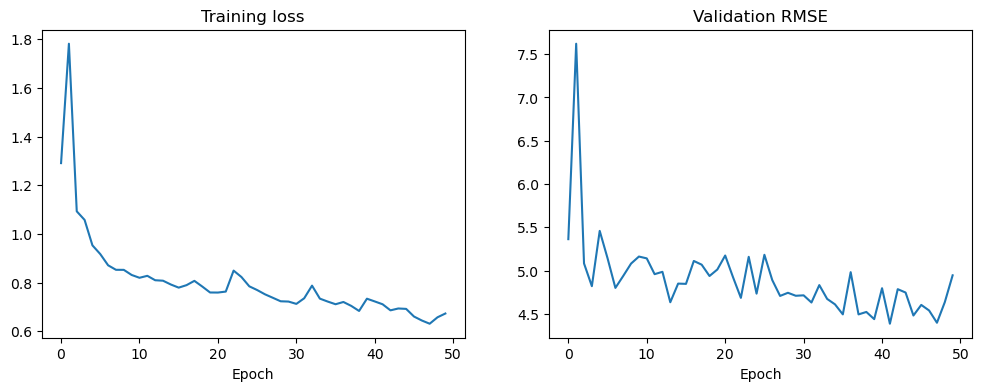

In [52]:
if b_Retrain_Model:
    losses = []
    val_rmses = []
    n_max_epoch = 50
    
    val_rmse_best = np.inf
    trainer = Trainer(model, lr=5e-5)
    for epoch in range(n_max_epoch):
        train_tasks = gen_tasks(train_range)
        batch_losses = trainer(train_tasks)
        losses.append(np.mean(batch_losses))
        val_rmses.append(compute_val_rmse(model, val_tasks))
        if val_rmses[-1] < val_rmse_best:
            val_rmse_best = val_rmses[-1]
            # Fix a bug: JSON is not able to encode numpy float32:
            model.config['encoder_scales'] = [float(number) for number in model.config['encoder_scales']]
            model.save(processor_dir)
        print('Training epoch {} of {}; loss {}'.format(epoch+1,n_max_epoch,val_rmse_best))
              
    # visualize loss function improvement
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(losses)
    axes[1].plot(val_rmses)
    _ = axes[0].set_xlabel("Epoch")
    _ = axes[1].set_xlabel("Epoch")
    _ = axes[0].set_title("Training loss")
    _ = axes[1].set_title("Validation RMSE")
    
    # save to CSV
    pd.DataFrame({'Epoch':np.arange(0,n_max_epoch),'Training Loss':losses,'Validation RMSE':val_rmses}).to_csv(os.path.join(processor_dir,'training_log.csv'))


## Visualize Trained Model Output

In [53]:
# Pick a result to plot
# date = '2024-02-17T03:30:00' # Note: in training set
# date = '2024-03-01T02:30:00' # Note: in training set
date = '2024-03-10T01:30:00' # Note: in validation set
test_task = task_loader(date, context_sampling=["all", "all", "all", "all"], target_sampling="all")
# Define a complete set of coordinates for evaluation:
X_t_all = xr.Dataset({'target':xr.DataArray(np.nan,dims=('lat','lon'),coords={'lat':np.arange(36,38,0.01),'lon':np.arange(126,128,0.01)})})
# Predict outputs:
pred = model.predict(test_task, X_t=X_t_all, resolution_factor=1)

pred

{'NO2': <xarray.Dataset> Size: 323kB
 Dimensions:  (time: 1, lat: 200, lon: 200)
 Coordinates:
   * lat      (lat) float64 2kB 36.0 36.01 36.02 36.03 ... 37.97 37.98 37.99
   * lon      (lon) float64 2kB 126.0 126.0 126.0 126.0 ... 128.0 128.0 128.0
   * time     (time) datetime64[ns] 8B 2024-03-10T01:30:00
 Data variables:
     mean     (time, lat, lon) float32 160kB 8.039 7.75 7.591 ... 6.13 6.338
     std      (time, lat, lon) float32 160kB 2.047 2.05 2.045 ... 0.9671 0.9914}

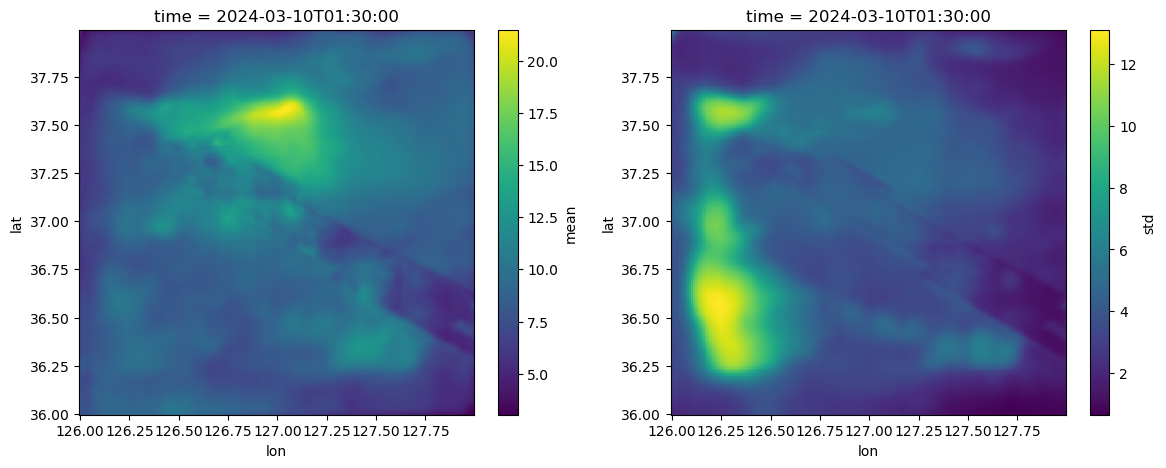

In [59]:
# visualize the prediction
# Plotting doesn't work properly since the shapefiles for the region can't be accessed on Discover.
# o_fig_out = deepsensor.plot.prediction(pred, date, data_processor, task_loader, test_task, crs=ccrs.PlateCarree())
# plt.show()

o_fig_out, o_ax_out = plt.subplots(1,2,figsize=(14, 5))
pred['NO2']['mean'].squeeze('time').plot(ax=o_ax_out[0])
pred['NO2']['std'].squeeze('time').plot(ax=o_ax_out[1])
plt.show()


In [100]:
# helper function: plotting on a map
def f_plot_map(a_data_plot,
               a_data_plot_point=None,
               n_lat_min=-90,
               n_lat_max=90,
               n_lon_min=-180,
               n_lon_max=180,
               my_cmap = plt.get_cmap('Blues'),
               Colorbar_Label = None,
               Plot_Title = None,
               Colorbar_Limits = None,
               n_pointsize = 20,
               o_figure = None,
               o_axis = None,
               o_plot = None,
               SHOW=True):
  if o_figure is None:
      o_figure,o_axis = plt.subplots(1,1)
      o_axis.remove()
      o_axis = o_figure.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
      # mapobj = plt.figure().add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
      # mapobj = mapobj.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())

  # mapobj.coastlines();
  # mapobj.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none', linestyle='-');
  # mapobj.set_extent([np.max([n_lon_min,-180])-0.001, np.min([n_lon_max,180])+0.001, np.max([n_lat_min,-90])-0.001, np.min([n_lat_max,90])+0.001])
  o_axis.set_extent([np.max([n_lon_min,-180])-0.001, np.min([n_lon_max,180])+0.001, np.max([n_lat_min,-90])-0.001, np.min([n_lat_max,90])+0.001])
  gridlines = o_axis.gridlines(crs=cartopy.crs.PlateCarree(), xlocs=range(np.int_(np.floor(np.max([n_lon_min,-180]))),np.int_(np.ceil(np.min([n_lon_max,180])))+1), ylocs=range(np.int_(np.floor(np.max([n_lat_min,-90]))),np.int_(np.ceil(np.min([n_lat_max,90])))+1), draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
  gridlines.top_labels = False
  gridlines.right_labels = False
  if 'time' in a_data_plot.dims:
      # take average for plotting:
      a_data_plot = a_data_plot.mean(dim='time')
  if Colorbar_Limits is None:
      if Colorbar_Label is not None:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,cbar_kwargs={'label': Colorbar_Label})
      else:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap)
  else:
      if Colorbar_Label is not None:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cbar_kwargs={'label': Colorbar_Label})
      else:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1])
  if a_data_plot_point is not None:
    if type(a_data_plot_point) is pd.Series:
        f_data_plot_point = a_data_plot_point
        if 'time' in f_data_plot_point.index.names:
            f_data_plot_point = f_data_plot_point.groupby(['lat','lon']).mean('time')
        v_lat_plot = f_data_plot_point.reset_index()['lat'].values
        v_lon_plot = f_data_plot_point.reset_index()['lon'].values
        v_data_temp = f_data_plot_point.values
    else:
        v_lat_plot = np.array(a_data_plot_point.lat)
        v_lon_plot = np.array(a_data_plot_point.lon)
        if 'time' in a_data_plot_point.dims:
          # take average for plotting:
          v_data_temp = np.array(a_data_plot_point.mean(dim='time'))
        else:
          v_data_temp = np.array(a_data_plot_point)
    if Colorbar_Limits is None:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,cmap=my_cmap)
    else:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cmap=my_cmap)
#    if Colorbar_Label is not None:
#      o_axis.colorbar().set_label(Colorbar_Label)
#    else:
#      o_axis.colorbar()
  if Plot_Title is not None:
    o_axis.set_title(Plot_Title)
  if SHOW:
    o_figure.show()
  return o_figure,o_axis,o_plot

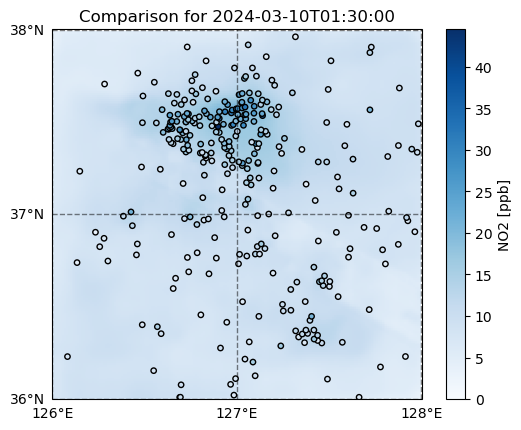

In [101]:
# plot results for comparison
o_fig,o_ax,o_plot =  f_plot_map(pred['NO2']['mean'].mean('time'),
                                a_data_plot_point = f_data_airkorea_aligned.loc[date]['NO2'],
                                n_lat_min=36,
                                n_lat_max=38,
                                n_lon_min=126,
                                n_lon_max=128,
                                my_cmap = plt.get_cmap('Blues'),
                                Colorbar_Label = 'NO2 [ppb]',
                                Plot_Title = f'Comparison for {date}',
                                Colorbar_Limits = (0,f_data_airkorea_aligned.loc[date]['NO2'].max()),
                                n_pointsize=15)

# Next Steps to be worked on
 - Randomization of training data across epochs
 - Quantitative evaluation of performance
   - compare to interpolation (or nearest) ground station
   - compare to GEOS-CF
 - Augment training data with rotations
 - Add additional context information
   - Higher resolution emissions
   - Population
   - Land use/cover
   - ~~time-of-day indicators~~
 - Test when inputs (e.g., GCAS) are missing: look at nighttime predictions
 - Include some ground stations as inputs; set-up appropriate cross-validation
 - Evaluate importance of different input types
 - ~~Work on importing context data at original resolutions to avoid need for regridding?~~
   - ~~This would allow much easier predictions at other times since there wouldn't need to be a high-res gridded dataset of everything to pull from~~